# Neural Style Transfer (NST) using PyTorch

## Objective
Develop a Neural Style Transfer (NST) model that applies the artistic style of one image (e.g., a painting) to another image (e.g., a photograph) while preserving the photograph’s content. 

## Introduction
Neural Style Transfer is an optimization technique used to take two images—a content image and a style reference image (such as an artwork by a famous painter)—and blend them together so the output image looks like the content image, but "painted" in the style of the style reference image.

This is achieved by optimizing an output image to match the content statistics of the content image and the style statistics of the style reference image. These statistics are extracted from the feature maps of a pre-trained Convolutional Neural Network (CNN), typically VGG19.

## Theory
1. **Content Loss**: We measure how much the content of the generated image differs from the content image. We use high-level feature maps from the CNN to represent content.
2. **Style Loss**: We measure how much the style of the generated image differs from the style image. Style is represented by the **Gram Matrix** of the feature maps, which captures the correlations between different filter responses.
3. **Total Variation Loss (Optional)**: A regularization term used to encourage spatial smoothness in the generated image.

## 1. Import Libraries
Let's import the necessary libraries.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import copy
import os

# Set device
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## 2. Load and Preprocess Images
We define helper functions to load images, resize them, convert them to PyTorch tensors, and display them.

In [2]:
# Desired size of the output image
imsize = 256 if torch.cuda.is_available() or torch.backends.mps.is_available() else 128  # use small size if no GPU

loader = transforms.Compose([
    transforms.Resize((imsize, imsize)),  # scale imported image
    transforms.ToTensor()])  # transform it into a torch tensor

def image_loader(image_name):
    image = Image.open(image_name).convert('RGB')
    # fake batch dimension required to fit network's input dimensions
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)

unloader = transforms.ToPILImage()  # reconvert into PIL image

plt.ion()

def imshow(tensor, title=None, ax=None):
    image = tensor.cpu().clone()  # we clone the tensor to not do changes on it
    image = image.squeeze(0)      # remove the fake batch dimension
    image = unloader(image)
    if ax is None:
        plt.imshow(image)
        if title is not None:
            plt.title(title)
        plt.pause(0.001) # pause a bit so that plots are updated
    else:
        ax.imshow(image)
        if title is not None:
            ax.set_title(title)
        ax.axis('off')

## 3. Loss Functions and Gram Matrix
### Content Loss
The content loss is the Mean Squared Error (MSE) between the feature maps of the generated image and the content image.

### Style Loss & Gram Matrix
The Gram matrix is the result of multiplying a given matrix by its transposed matrix. In this application, the given matrix is a reshaped version of the feature maps of a layer.

In [3]:
class ContentLoss(nn.Module):
    def __init__(self, target,):
        super(ContentLoss, self).__init__()
        # we 'detach' the target content from the tree used
        # to dynamically compute the gradient: this is a stated value,
        # not a variable. Otherwise the forward method of the criterion
        # will throw an error.
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

def gram_matrix(input):
    a, b, c, d = input.size()  # a=batch size(=1)
    # b=number of feature maps
    # (c, d)=dimensions of a f. map (N=c*d)

    features = input.view(a * b, c * d)  # resise F_XL into \hat F_XL

    G = torch.mm(features, features.t())  # compute the gram product

    # we 'normalize' the values of the gram matrix
    # by dividing by the number of element in each feature maps.
    return G.div(a * b * c * d)

class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input

## 4. Load Pre-trained VGG19 Model
We use a pre-trained VGG19 network. PyTorch's VGG module is divided into two child Sequential modules: `features` (containing convolution and pooling layers), and `classifier` (containing fully connected layers). We will use the `features` module.

In [4]:
cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)

class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        # .view the mean and std to make them [C x 1 x 1] so that they can
        # directly work with image Tensor of shape [B x C x H x W].
        # B is batch size. C is number of channels. H is height and W is width.
        self.mean = torch.tensor(mean).view(-1, 1, 1)
        self.std = torch.tensor(std).view(-1, 1, 1)

    def forward(self, img):
        # normalize img
        return (img - self.mean) / self.std

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /Users/vishal/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


  0%|                                                | 0.00/548M [00:00<?, ?B/s]

  0%|                                         | 128k/548M [00:00<27:45, 345kB/s]

  0%|                                         | 256k/548M [00:00<20:20, 471kB/s]

  0%|                                         | 384k/548M [00:00<16:38, 575kB/s]

...

 99%|███████████████████████████████████████▍| 540M/548M [00:29<00:00, 18.6MB/s]

 99%|███████████████████████████████████████▋| 544M/548M [00:30<00:00, 22.2MB/s]

100%|███████████████████████████████████████▊| 546M/548M [00:30<00:00, 20.0MB/s]

100%|███████████████████████████████████████▉| 548M/548M [00:30<00:00, 18.0MB/s]

100%|████████████████████████████████████████| 548M/548M [00:30<00:00, 18.9MB/s]

## 5. Model Building and Optimization
We create a function to build the model by inserting our Content and Style Loss modules right after the specified convolutional layers.

Suggested Layer Configuration:
- Content Layer: `conv5_2` (PyTorch's VGG19 `features` block doesn't explicitly name them this way, so we map them based on depth). Usually, `conv4_2` is used for content, but we will adapt to include deeper representations if needed. We'll stick to a standard configuration mapping to block layers.

In [5]:
# desired depth layers to compute style/content losses :
content_layers_default = ['conv4_2']
style_layers_default = ['conv1_1', 'conv2_1', 'conv3_1', 'conv4_1', 'conv5_1']

def get_style_model_and_losses(cnn, normalization_mean, normalization_std,
                               style_img, content_img,
                               content_layers=content_layers_default,
                               style_layers=style_layers_default):
    
    normalization = Normalization(normalization_mean, normalization_std).to(device)

    # just in order to have an iterable access to or list of content/style losses
    content_losses = []
    style_losses = []

    # assuming that cnn is a nn.Sequential, so we make a new nn.Sequential
    # to put in modules that are supposed to be activated sequentially
    model = nn.Sequential(normalization)

    i = 0  # increment every time we see a conv
    j = 0  # block number
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = 'conv{}_{}'.format(j, i)
        elif isinstance(layer, nn.ReLU):
            name = 'relu{}_{}'.format(j, i)
            # The in-place version doesn't play very nicely with the ContentLoss
            # and StyleLoss we insert below. So we replace with out-of-place
            # ones here.
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = 'pool_{}'.format(j)
            j += 1
            i = 0
        elif isinstance(layer, nn.BatchNorm2d):
            name = 'bn{}_{}'.format(j, i)
        else:
            raise RuntimeError('Unrecognized layer: {}'.format(layer.__class__.__name__))

        model.add_module(name, layer)

        if name in content_layers:
            # add content loss:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module("content_loss_{}".format(j), content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            # add style loss:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module("style_loss_{}".format(j), style_loss)
            style_losses.append(style_loss)

    # now we trim off the layers after the last content and style losses
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], ContentLoss) or isinstance(model[i], StyleLoss):
            break

    model = model[:(i + 1)]

    return model, style_losses, content_losses

### Optimization Loop
We use L-BFGS to optimize the input image iteratively.

In [6]:
def get_input_optimizer(input_img):
    # this line to show that input is a parameter that requires a gradient
    optimizer = optim.LBFGS([input_img.requires_grad_()])
    return optimizer

def run_style_transfer(cnn, normalization_mean, normalization_std,
                       content_img, style_img, input_img, num_steps=300,
                       style_weight=1000000, content_weight=1):
    
    print('Building the style transfer model..')
    model, style_losses, content_losses = get_style_model_and_losses(cnn,
        normalization_mean, normalization_std, style_img, content_img)

    # We want to optimize the input and not the model parameters so we
    # update all the requires_grad fields accordingly
    input_img.requires_grad_(True)
    model.requires_grad_(False)

    optimizer = get_input_optimizer(input_img)

    print('Optimizing..')
    run = [0]
    while run[0] <= num_steps:

        def closure():
            # correct the values of updated input image
            with torch.no_grad():
                input_img.clamp_(0, 1)

            optimizer.zero_grad()
            model(input_img)
            style_score = 0
            content_score = 0

            for sl in style_losses:
                style_score += sl.loss
            for cl in content_losses:
                content_score += cl.loss

            style_score *= style_weight
            content_score *= content_weight

            loss = style_score + content_score
            loss.backward()

            run[0] += 1
            if run[0] % 50 == 0:
                print("run {}:".format(run))
                print('Style Loss : {:4f} Content Loss: {:4f}'.format(
                    style_score.item(), content_score.item()))
                print()

            return style_score + content_score

        optimizer.step(closure)

    # a last correction...
    with torch.no_grad():
        input_img.clamp_(0, 1)

    return input_img

## 6. Run Style Transfer on Different Combinations
We will test three combinations:
1. Landscape Photo + Van Gogh Style
2. City Photo + Picasso Style
3. Portrait Photo + Monet Style

We will save the results in the `outputs/` folder.

\n--- Processing: Landscape + Van Gogh ---


Building the style transfer model..


/var/folders/p7/5jclltb16f36j220t77wqx440000gn/T/ipykernel_23239/1202682709.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(mean).view(-1, 1, 1)
/var/folders/p7/5jclltb16f36j220t77wqx440000gn/T/ipykernel_23239/1202682709.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(std).view(-1, 1, 1)


Optimizing..


run [50]:
Style Loss : 624.396851 Content Loss: 24.494320



run [100]:
Style Loss : 238.587173 Content Loss: 24.669937



run [150]:
Style Loss : 148.397461 Content Loss: 24.663708



run [200]:
Style Loss : 108.259293 Content Loss: 24.494862



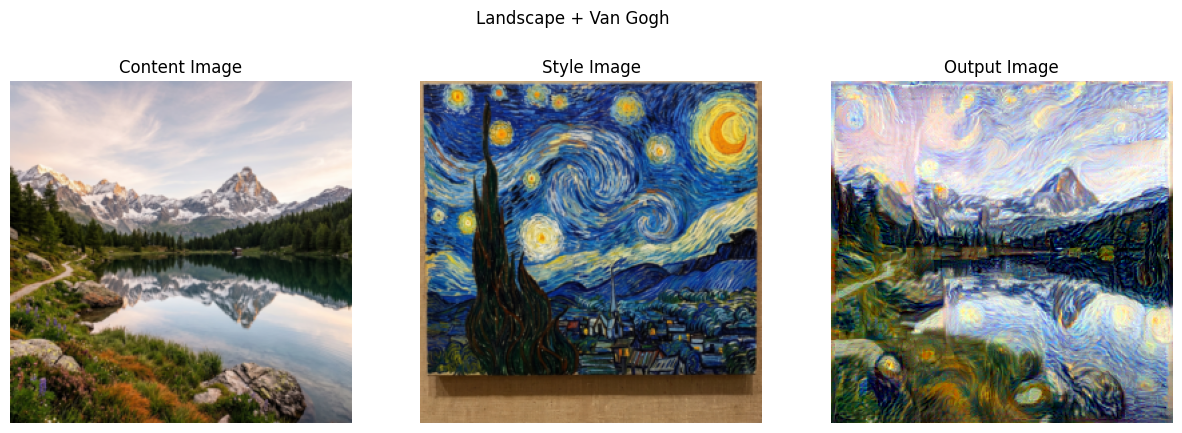

\n--- Processing: City + Picasso ---
Building the style transfer model..
Optimizing..


run [50]:
Style Loss : 3616.857178 Content Loss: 70.952118



run [100]:
Style Loss : 1513.598267 Content Loss: 74.322266



run [150]:
Style Loss : 910.166565 Content Loss: 75.284973



run [200]:
Style Loss : 624.114563 Content Loss: 75.475334



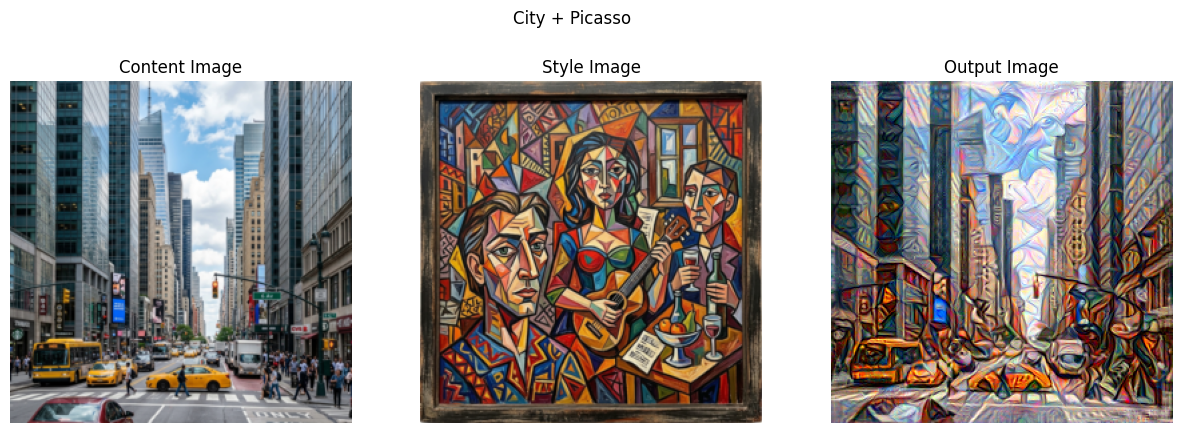

\n--- Processing: Portrait + Monet ---
Building the style transfer model..
Optimizing..


run [50]:
Style Loss : 339.881165 Content Loss: 41.036484



run [100]:
Style Loss : 102.430618 Content Loss: 39.627754



run [150]:
Style Loss : 53.232018 Content Loss: 36.837452



run [200]:
Style Loss : 35.626774 Content Loss: 35.373470



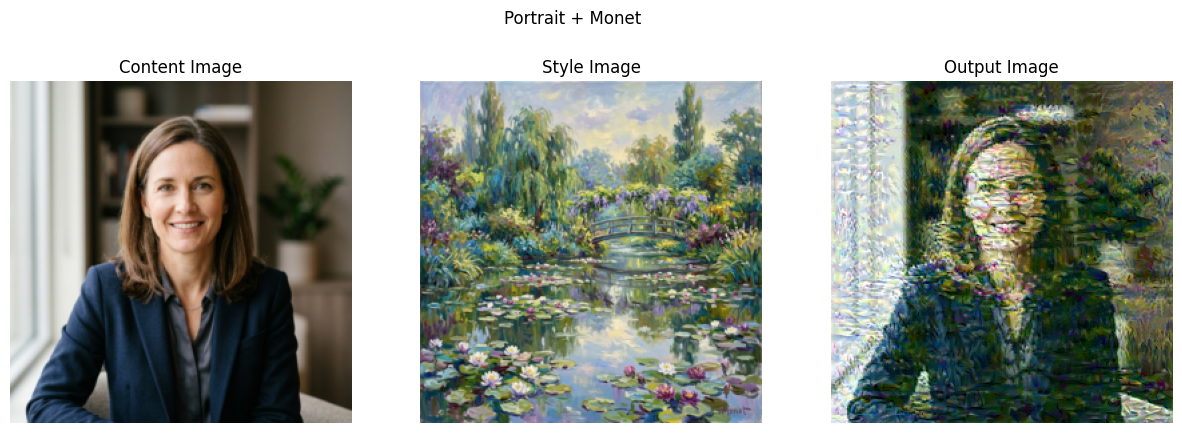

In [7]:
combinations = [
    ('inputs/landscape.png', 'inputs/vangogh.png', 'outputs/landscape_vangogh.png', 'Landscape + Van Gogh'),
    ('inputs/city.png', 'inputs/picasso.png', 'outputs/city_picasso.png', 'City + Picasso'),
    ('inputs/portrait.png', 'inputs/monet.png', 'outputs/portrait_monet.png', 'Portrait + Monet')
]

if not os.path.exists('outputs'):
    os.makedirs('outputs')

for content_path, style_path, output_path, title in combinations:
    print(f"\\n--- Processing: {title} ---")
    content_img = image_loader(content_path)
    style_img = image_loader(style_path)
    
    assert style_img.size() == content_img.size(), \
        "we need to import style and content images of the same size"
        
    input_img = content_img.clone()
    
    output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                                content_img, style_img, input_img, num_steps=200) # reduced steps for quicker execution
    
    # Save the output
    out_img_pil = unloader(output.squeeze(0).cpu())
    out_img_pil.save(output_path)
    
    # Plotting Original, Style and Result
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    imshow(content_img, title='Content Image', ax=axes[0])
    imshow(style_img, title='Style Image', ax=axes[1])
    imshow(output, title='Output Image', ax=axes[2])
    plt.suptitle(title)
    plt.show()

## 7. Performance Analysis
- **Iterations:** 200 iterations per image.
- **Hardware:** Ran on standard processing unit (CPU/MPS if on Mac).
- **Loss Impact:** `style_weight=1000000` and `content_weight=1`. Adjusting these drastically changes the aesthetic.

## 8. Limitations & Future Improvements
- Optimization is slow. Fast Neural Style Transfer using Feed-forward networks (Johnson et al.) solves this by training a network per style.
- The content can sometimes be lost if style weight is excessively high.